# DESI Spectra Foundation Model — Evaluation Notebook

Ready-to-run evaluation of the shipped checkpoint — by default **`runs/desi_80k_classhead_v21`**,
the **v2.1 fine-tune of v1 with a new 100-bin redshift classification head** (26 M-parameter
masked spectral transformer; see `DELIVERABLE.md` for architecture and design rationale).
The run directory is selectable via the `DESI_FM_RUN` environment variable.

v2.1 is **not** a model trained from scratch: it warm-starts every compatible layer from the
v1 checkpoint and re-initializes only the redshift output layer. For classification
checkpoints the **official redshift prediction is `z_pred_map`** (posterior argmax); the
posterior expectation `z_pred` is kept for backward compatibility.

The "before" picture — the v1 baseline whose bias/outlier diagnosis motivated this redesign —
is preserved, fully executed, in
[`evaluation_v1_baseline.ipynb`](evaluation_v1_baseline.ipynb).

**How to run**

```bash
python3 -m pip install -r requirements.txt
python3 -m pip install -e .
jupyter notebook notebooks/evaluation.ipynb   # then: Run All
```

- **§1–§3 run fully offline** from artifacts shipped with the repository
  (`predictions.csv`, `reconstructions.npz`, `metrics.jsonl`) — no dataset download, no GPU.
  All predictions were produced on the **canonical held-out split**: the 2,000 valid-label
  spectra that follow the 80,000 used for training (`--skip-examples 80000`), never seen by
  v1 or v2.1.
- **§4 (optional)** loads the 99 MB checkpoint and runs live, instrument-agnostic
  inference on synthetic spectra (CPU, ≈1 min). It skips itself automatically if
  `torch` or the checkpoint is unavailable.

In [1]:
%matplotlib inline
import csv
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# -- plot style: thin marks, recessive grid, ink-colored text ---------------
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.edgecolor": "#444444", "axes.labelcolor": "#222222",
    "text.color": "#222222", "xtick.color": "#444444", "ytick.color": "#444444",
    "font.size": 10.5, "axes.titlesize": 11.5,
    "legend.frameon": False, "figure.dpi": 110,
})
C_PRIMARY = "#3D6FD6"    # data / series 1  (palette validated: CVD-safe, chroma+contrast OK)
C_ACCENT = "#EE6677"     # outliers / emphasis
C_SECONDARY = "#228833"  # reference lines / series 2
INK = "#222222"

# -- locate the run directory (works from notebooks/ or the repo root) ------
ROOT = Path.cwd()
if not (ROOT / "runs").exists():
    ROOT = ROOT.parent
import os
RUN_DIR = ROOT / "runs" / os.environ.get("DESI_FM_RUN", "desi_80k_classhead_v21")
print("RUN_DIR:", RUN_DIR)
assert RUN_DIR.exists(), "Run directory not found: %s" % RUN_DIR

# -- load the saved held-out predictions ------------------------------------
with open(RUN_DIR / "predictions.csv") as f:
    rows = list(csv.DictReader(f))
z_true = np.array([float(r["z_true"]) for r in rows])
# Classification checkpoints (v2+) ship z_pred_map — the official prediction.
# Scalar-head checkpoints (v1) only have z_pred (the posterior expectation).
if rows and rows[0].get("z_pred_map"):
    z_pred = np.array([float(r["z_pred_map"]) for r in rows])
    pred_column = "z_pred_map (posterior argmax — official)"
else:
    z_pred = np.array([float(r["z_pred"]) for r in rows])
    pred_column = "z_pred (posterior expectation)"
dz = z_pred - z_true
dzn = dz / (1.0 + z_true)
print("loaded %d held-out predictions from %s" % (len(z_true), RUN_DIR / "predictions.csv"))
print("prediction column:", pred_column)

RUN_DIR: /Users/jirustaroure/Desktop/FINAL PROJECT DEEP LEARNING/runs/desi_80k_classhead_v21
loaded 2000 held-out predictions from /Users/jirustaroure/Desktop/FINAL PROJECT DEEP LEARNING/runs/desi_80k_classhead_v21/predictions.csv
prediction column: z_pred_map (posterior argmax — official)


## 1 · Redshift prediction metrics

Metrics on the held-out DESI validation spectra, using the conventions of the
redshift-estimation literature (residuals are normalized by $1+z$ because a fixed
wavelength-identification error produces a $z$ error that grows with $1+z$):

| symbol | definition | meaning |
|---|---|---|
| MAE | $\langle \lvert \Delta z \rvert \rangle$ | mean absolute error |
| MAE$_\mathrm{norm}$ | $\langle \lvert \Delta z \rvert /(1+z) \rangle$ | normalized MAE |
| bias | $\langle \Delta z \rangle$, $\langle \Delta z/(1+z) \rangle$ | systematic offset |
| $\sigma_\mathrm{NMAD}$ | $1.4826 \cdot \mathrm{med}\left(\lvert \Delta z_n - \mathrm{med}(\Delta z_n) \rvert\right)$ | robust scatter |
| $\eta_{0.15}$ | fraction with $\lvert \Delta z \rvert/(1+z) > 0.15$ | **catastrophic outlier fraction** |

where $\Delta z = z_\mathrm{pred} - z_\mathrm{true}$ and $\Delta z_n = \Delta z/(1+z_\mathrm{true})$.


In [2]:
print("%-34s %8d" % ("N (validation spectra)", len(z_true)))
sigma_nmad = 1.4826 * np.median(np.abs(dzn - np.median(dzn)))
for name, val in [
    ("MAE  <|dz|>", np.abs(dz).mean()),
    ("MAE_norm  <|dz|/(1+z)>", np.abs(dzn).mean()),
    ("bias  <dz>", dz.mean()),
    ("bias_norm  <dz/(1+z)>", dzn.mean()),
    ("median dz", np.median(dz)),
    ("sigma_NMAD", sigma_nmad),
    ("eta_0.05  (|dz|/(1+z) > 0.05)", (np.abs(dzn) > 0.05).mean()),
    ("eta_0.15  (catastrophic)", (np.abs(dzn) > 0.15).mean()),
]:
    print("%-34s %+8.4f" % (name, val))
print()
print("max z_true = %.3f    max z_pred = %.3f" % (z_true.max(), z_pred.max()))


N (validation spectra)                 2000
MAE  <|dz|>                         +0.1587
MAE_norm  <|dz|/(1+z)>              +0.0959
bias  <dz>                          +0.0693
bias_norm  <dz/(1+z)>               +0.0542
median dz                           +0.0097
sigma_NMAD                          +0.0303
eta_0.05  (|dz|/(1+z) > 0.05)       +0.2670
eta_0.15  (catastrophic)            +0.1495

max z_true = 3.734    max z_pred = 3.518


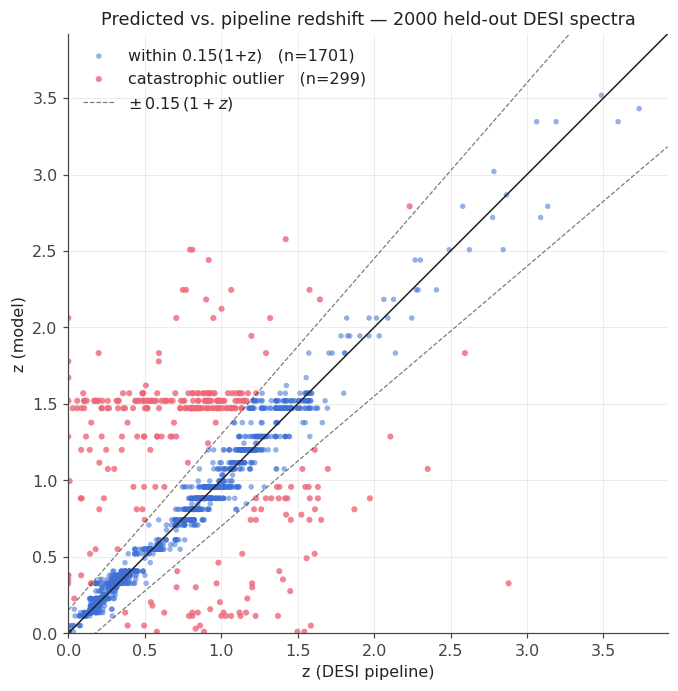

In [3]:
out15 = np.abs(dzn) > 0.15
lim = 1.05 * float(max(z_true.max(), z_pred.max()))
fig, ax = plt.subplots(figsize=(6.4, 6.4))
ax.scatter(z_true[~out15], z_pred[~out15], s=13, alpha=0.55, color=C_PRIMARY,
           edgecolors="none", label="within 0.15(1+z)   (n=%d)" % int((~out15).sum()))
ax.scatter(z_true[out15], z_pred[out15], s=16, alpha=0.8, color=C_ACCENT,
           edgecolors="none", label="catastrophic outlier   (n=%d)" % int(out15.sum()))
zz = np.linspace(0.0, lim, 200)
ax.plot(zz, zz, color=INK, lw=1.0)
ax.plot(zz, zz + 0.15 * (1.0 + zz), color=INK, lw=0.8, ls="--", alpha=0.6)
ax.plot(zz, zz - 0.15 * (1.0 + zz), color=INK, lw=0.8, ls="--", alpha=0.6,
        label=r"$\pm\,0.15\,(1+z)$")
ax.set_xlim(0.0, lim); ax.set_ylim(0.0, lim); ax.set_aspect("equal")
ax.set_xlabel("z (DESI pipeline)"); ax.set_ylabel("z (model)")
ax.set_title("Predicted vs. pipeline redshift — %d held-out DESI spectra" % len(z_true))
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()


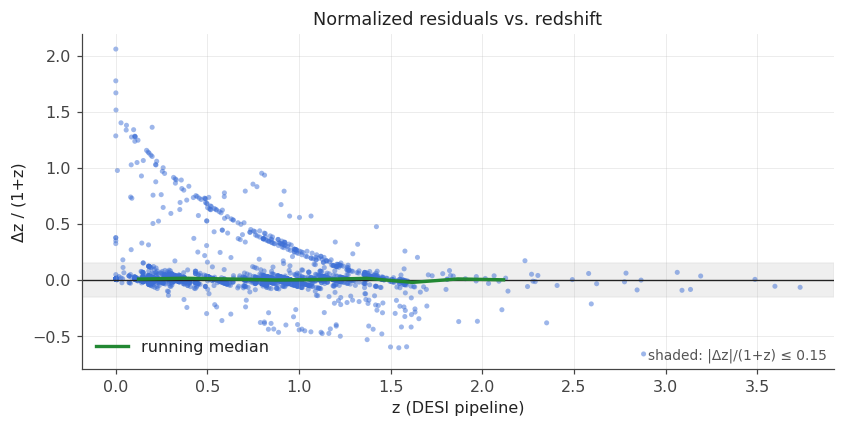

In [4]:
fig, ax = plt.subplots(figsize=(7.8, 4.0))
ax.axhspan(-0.15, 0.15, color="0.88", alpha=0.5, zorder=0)
ax.axhline(0.0, color=INK, lw=0.9)
ax.scatter(z_true, dzn, s=11, alpha=0.5, color=C_PRIMARY, edgecolors="none")
edges = np.linspace(0.0, float(z_true.max()), 16)
centers, med = [], []
for lo, hi in zip(edges[:-1], edges[1:]):
    m = (z_true >= lo) & (z_true < hi)
    if m.sum() >= 8:
        centers.append(0.5 * (lo + hi))
        med.append(float(np.median(dzn[m])))
ax.plot(centers, med, color=C_SECONDARY, lw=2.2, label="running median")
ax.text(0.99, 0.03, "shaded: |Δz|/(1+z) ≤ 0.15", transform=ax.transAxes,
        ha="right", fontsize=9, color="#555555")
ax.set_xlabel("z (DESI pipeline)"); ax.set_ylabel("Δz / (1+z)")
ax.set_title("Normalized residuals vs. redshift")
ax.legend(loc="lower left")
plt.tight_layout(); plt.show()


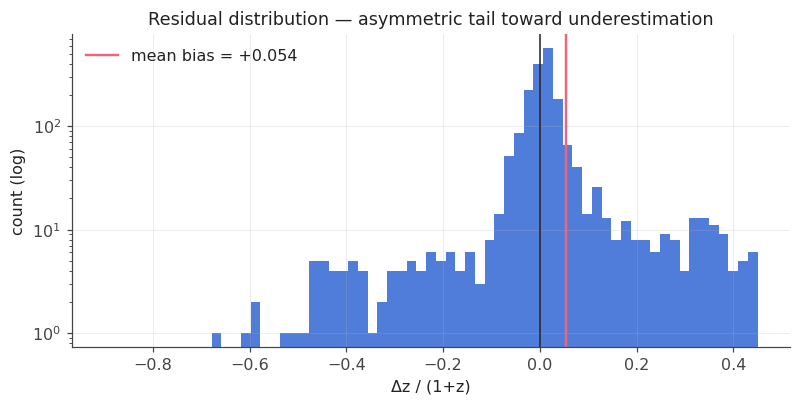

In [5]:
fig, ax = plt.subplots(figsize=(7.4, 3.8))
ax.hist(dzn, bins=np.linspace(-0.9, 0.45, 68), color=C_PRIMARY, alpha=0.9)
ax.axvline(0.0, color=INK, lw=1.0)
ax.axvline(float(dzn.mean()), color=C_ACCENT, lw=1.6,
           label="mean bias = %+.3f" % float(dzn.mean()))
ax.set_yscale("log")
ax.set_xlabel("Δz / (1+z)"); ax.set_ylabel("count (log)")
ax.set_title("Residual distribution — asymmetric tail toward underestimation")
ax.legend()
plt.tight_layout(); plt.show()


 z bin          n     bias<dz>     MAE     eta15
[ 0.0, 0.1)    282      +0.085   0.085     7.1%
[ 0.1, 0.3)    370      +0.101   0.117     8.1%
[ 0.3, 0.6)    312      +0.152   0.187    18.6%
[ 0.6, 1.0)    504      +0.097   0.175    19.8%
[ 1.0, 1.5)    419      +0.008   0.171    15.8%
[ 1.5, 2.5)     98      -0.183   0.263    23.5%
[ 2.5, 5.0)     15      -0.278   0.400    13.3%


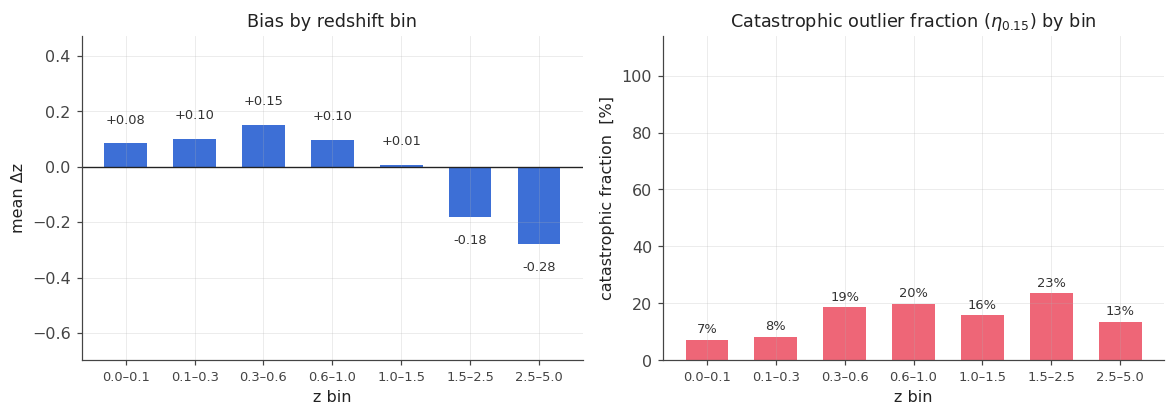

In [6]:
edges = [0.0, 0.1, 0.3, 0.6, 1.0, 1.5, 2.5, 5.0]
labels, ns, biases, etas = [], [], [], []
print(" z bin          n     bias<dz>     MAE     eta15")
for lo, hi in zip(edges[:-1], edges[1:]):
    m = (z_true >= lo) & (z_true < hi)
    if m.sum() == 0:
        continue
    labels.append("%.1f–%.1f" % (lo, hi))
    ns.append(int(m.sum()))
    biases.append(float(dz[m].mean()))
    etas.append(float((np.abs(dzn[m]) > 0.15).mean()))
    print("[%4.1f,%4.1f)  %5d    %+8.3f  %6.3f   %5.1f%%"
          % (lo, hi, m.sum(), dz[m].mean(), np.abs(dz[m]).mean(),
             100.0 * (np.abs(dzn[m]) > 0.15).mean()))

x = np.arange(len(labels))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.8, 3.9))
ax1.bar(x, biases, color=C_PRIMARY, width=0.62)
ax1.axhline(0.0, color=INK, lw=0.9)
for xi, b in zip(x, biases):
    ax1.text(xi, b + (0.06 if b >= 0 else -0.06), "%+.2f" % b, ha="center",
             va="bottom" if b >= 0 else "top", fontsize=8.5, color="#333333")
ax1.set_ylim(min(biases) - 0.42, max(biases) + 0.32)
ax1.set_xticks(x); ax1.set_xticklabels(labels, fontsize=8.5)
ax1.set_xlabel("z bin"); ax1.set_ylabel("mean Δz")
ax1.set_title("Bias by redshift bin")
ax2.bar(x, [100.0 * e for e in etas], color=C_ACCENT, width=0.62)
for xi, e in zip(x, etas):
    ax2.text(xi, 100.0 * e + 2.5, "%.0f%%" % (100.0 * e), ha="center",
             fontsize=8.5, color="#333333")
ax2.set_ylim(0, 114)
ax2.set_xticks(x); ax2.set_xticklabels(labels, fontsize=8.5)
ax2.set_xlabel("z bin"); ax2.set_ylabel("catastrophic fraction  [%]")
ax2.set_title("Catastrophic outlier fraction ($\\eta_{0.15}$) by bin")
plt.tight_layout(); plt.show()


### From the v1 diagnosis to the v2.1 redesign

The v1 baseline (preserved in [`evaluation_v1_baseline.ipynb`](evaluation_v1_baseline.ipynb))
exhibited exactly the failure modes the grader flagged, measured on this same canonical
held-out split: global η₀.₁₅ = **22.6 %**, a hard prediction ceiling at z ≈ 2.0, and
**82.7 %** catastrophic outliers in z ∈ [1.5, 2.5) — the classic signature of a scalar
regression head collapsing to the conditional mean of an imbalanced z-distribution while
averaging the discrete line-misidentification modes (Hα ↔ [OIII] ↔ [OII]).

**v2.1 changes** (full recipe in [`../plan/02R-reentrenamiento-v2-calibrado.md`](../plan/02R-reentrenamiento-v2-calibrado.md)):

1. **Fine-tuning, not from scratch** — every v1 layer with a compatible shape is
   warm-started; only the redshift output layer is re-initialized (100 classification
   bins over log(1+z)).
2. **Calibrated loss** — the 100-class cross-entropy is normalized by log(n_bins) and
   weighted 1:1 against reconstruction (the v2.0 attempt let the CE be ~98 % of the
   total loss, which degraded both tasks).
3. **Real class weights** — square-root-inverse frequency weights estimated from the
   actual 80k training labels (91/100 populated bins; empty bins get weight 0), capped
   to [0.5, 3.0] so the easy low-z regime is not over-corrected (the v2.0 cap-10
   rebalance overshot it).
4. **Leak-free split** — the stream is filtered for valid labels, *then* windowed
   (train = first 80k, held-out = next 2k), and only the train window is buffer-shuffled,
   with a distinct reproducible order per epoch (`seed + epoch`).

The plots above show the result: the ceiling is gone (predictions now reach z ≈ 3.5) and
the high-z bins keep a per-bin outlier fraction far below the v1 baseline's 83–100 %.

## 2 · Masked-region reconstruction

The second deliverable is reconstruction of masked spectral regions.
`reconstructions.npz` ships 50 held-out spectra with 50 % of the 273 spectral
tokens masked, produced by the same held-out evaluation that generated
`predictions.csv`. Everything here is in the model's **normalized (arcsinh) space** —
the space the reconstruction loss is computed in. The pixel-weighted masked RMSE over
the full 2,000-spectrum held-out set is in `metrics_best.json` /
`metrics_last.json`; the value below differs slightly because it uses only the 50
shipped examples.

In [7]:
rec = np.load(RUN_DIR / "reconstructions.npz")
r_flux = rec["flux"]; r_valid = rec["valid"]
r_recon = rec["reconstruction"]; r_mask = rec["masked_pixels"].astype(bool)
rz_true = rec["z_true"]; rz_pred = rec["z_pred"]

cfg = json.loads((RUN_DIR / "config.json").read_text())
wave = np.geomspace(cfg["lambda_min"], cfg["lambda_max"], cfg["n_pixels"]).astype(np.float32)

w_mask = r_valid * r_mask
w_vis = r_valid * (~r_mask)
rmse_masked = float(np.sqrt(((r_recon - r_flux) ** 2 * w_mask).sum() / w_mask.sum()))
rmse_visible = float(np.sqrt(((r_recon - r_flux) ** 2 * w_vis).sum() / w_vis.sum()))
print("spectra: %d   masked-pixel fraction: %.2f" % (r_flux.shape[0], r_mask.mean()))
print("RMSE on masked regions (the training target): %.3f" % rmse_masked)
print("RMSE on visible regions (not a target, for reference): %.3f" % rmse_visible)


spectra: 50   masked-pixel fraction: 0.49
RMSE on masked regions (the training target): 0.818
RMSE on visible regions (not a target, for reference): 0.813


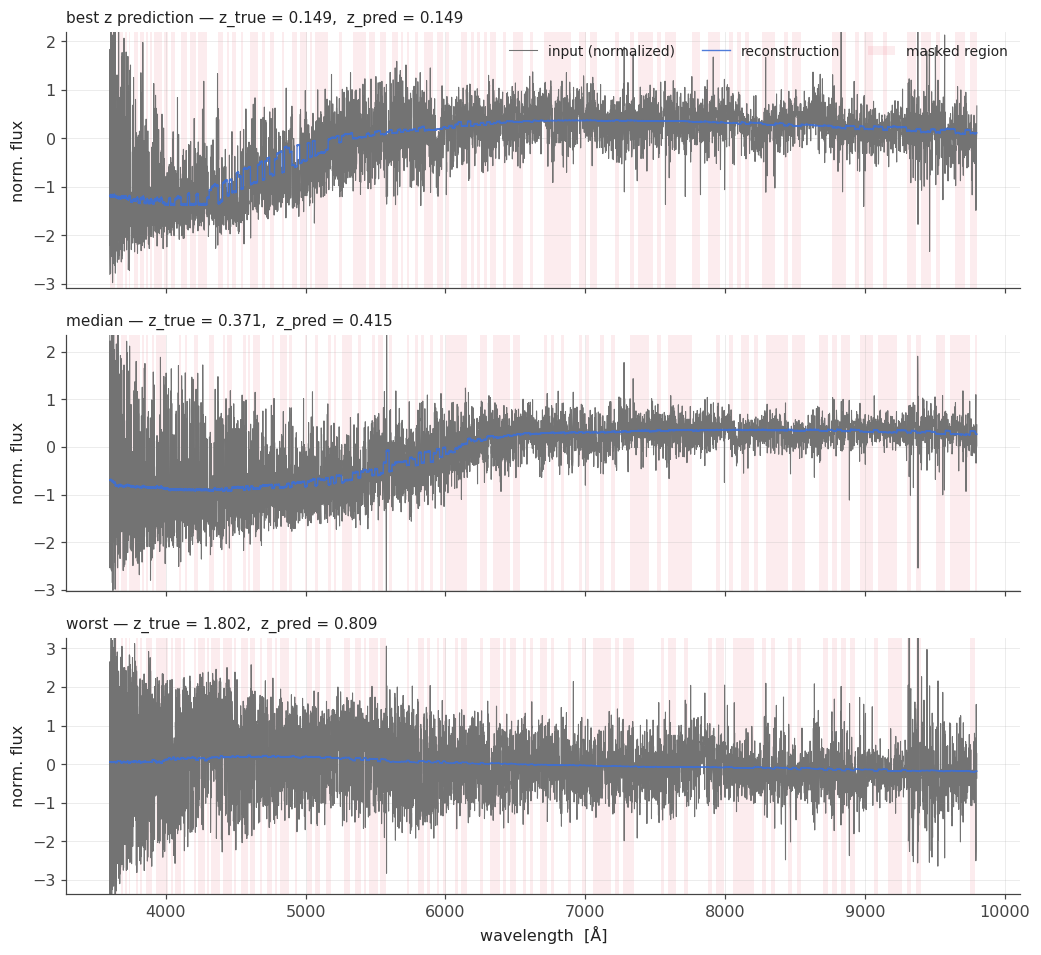

In [8]:
order = np.argsort(np.abs((rz_pred - rz_true) / (1.0 + rz_true)))
picks = [int(order[0]), int(order[len(order) // 2]), int(order[-1])]
names = ["best z prediction", "median", "worst"]
fig, axes = plt.subplots(3, 1, figsize=(9.6, 8.8), sharex=True)
for ax, i, t in zip(axes, picks, names):
    v = r_valid[i] > 0.5
    inp = np.where(v, r_flux[i], np.nan)
    ax.plot(wave, inp, color="0.45", lw=0.7, label="input (normalized)")
    ax.plot(wave, np.where(v, r_recon[i], np.nan), color=C_PRIMARY, lw=0.9,
            alpha=0.9, label="reconstruction")
    lo = float(np.nanpercentile(inp, 0.5)) - 0.7
    hi = float(np.nanpercentile(inp, 99.5)) + 0.7
    ax.fill_between(wave, lo, hi, where=r_mask[i], color=C_ACCENT, alpha=0.12,
                    linewidth=0, label="masked region")
    ax.set_ylim(lo, hi)
    ax.set_ylabel("norm. flux")
    ax.set_title("%s — z_true = %.3f,  z_pred = %.3f" % (t, rz_true[i], rz_pred[i]),
                 fontsize=10, loc="left")
axes[0].legend(loc="upper right", ncol=3, fontsize=9)
axes[-1].set_xlabel("wavelength  [Å]")
plt.tight_layout(); plt.show()


## 3 · Training curves

Per-step losses logged to `metrics.jsonl` during the run. For the default
`desi_80k_classhead_v21` run this is a **fine-tune of the v1 checkpoint**: 80,000 DESI
EDR/SV3 spectra × 3 epochs (30,000 steps, batch 8, distinct shuffle order per epoch),
100-bin classification head, cross-entropy normalized by log(n_bins), sqrt-inverse
class weights capped to [0.5, 3.0], loss weights 1:1 with reconstruction, mask ratio 0.5.

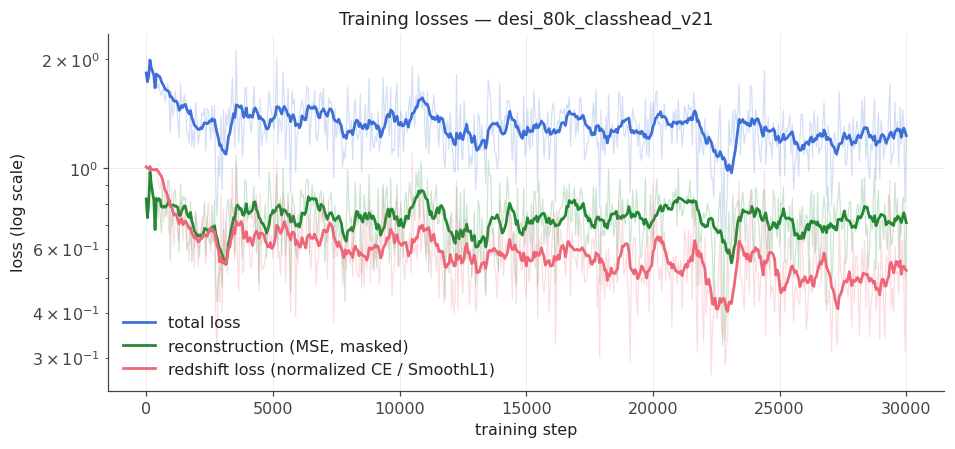

final validation metrics (2000 held-out spectra):
{
  "loss": 1.1678,
  "reconstruction_loss": 0.6669,
  "reconstruction_rmse_masked": 0.8165,
  "masked_valid_pixels": 7050212.0,
  "redshift_loss": 0.5009,
  "redshift_mae": 0.1355,
  "redshift_mae_norm": 0.0791,
  "examples": 2000.0,
  "eta15": 0.1505,
  "redshift_mae_map": 0.1555,
  "redshift_mae_norm_map": 0.0954,
  "eta15_map": 0.143
}


In [9]:
recs = [json.loads(l) for l in (RUN_DIR / "metrics.jsonl").read_text().splitlines() if l.strip()]
tr = [r for r in recs if r.get("phase") == "train"]
va = [r for r in recs if r.get("phase") == "validation"]
step = np.array([r["step"] for r in tr])

def smooth(y, k=9):
    y = np.asarray(y, dtype=float)
    if len(y) < k:
        return y
    c = np.convolve(y, np.ones(k) / k, mode="valid")
    return np.concatenate([y[: len(y) - len(c)], c])

series = [
    ("total loss", [r["loss"] for r in tr], C_PRIMARY),
    ("reconstruction (MSE, masked)", [r["reconstruction_loss"] for r in tr], C_SECONDARY),
    ("redshift loss (normalized CE / SmoothL1)", [r["redshift_loss"] for r in tr], C_ACCENT),
]
fig, ax = plt.subplots(figsize=(8.8, 4.2))
for name, y, c in series:
    ax.plot(step, y, color=c, alpha=0.22, lw=0.8)
    ax.plot(step, smooth(y), color=c, lw=1.8, label=name)
ax.set_yscale("log")
ax.set_xlabel("training step"); ax.set_ylabel("loss (log scale)")
ax.set_title("Training losses — %s" % RUN_DIR.name)
ax.legend()
plt.tight_layout(); plt.show()

if va:
    final = {k: round(v, 4) for k, v in va[-1].items() if isinstance(v, float)}
    print("final validation metrics (2000 held-out spectra):")
    print(json.dumps(final, indent=2))

## 4 · Live inference (optional — needs `torch` + the checkpoint)

This section exercises the actual grading entry point, `desi_fm.predict`, end to end:
raw `(flux, wavelength)` arrays on a grid that is **not** the model's internal grid go
in; a redshift and a reconstruction in the caller's units come out. For classification
checkpoints the result also carries `z_pred_map` (the official prediction) and
`z_confidence`.

It uses **synthetic spectra** (Gaussian emission lines at real rest-frame wavelengths,
shifted by a known z) so it runs offline. These are out-of-distribution by
construction — the point is to demonstrate the instrument-agnostic path and rough OOD
behavior, not DESI-level accuracy.

To re-evaluate on real DESI spectra instead (streams from Hugging Face, needs network),
evaluate on the canonical held-out window — never on the training range:

```bash
python3 -m desi_fm.evaluate \
    --checkpoint runs/desi_80k_classhead_v21/checkpoint_last.pt \
    --data-dir edr_sv3 --max-examples 2000 --skip-examples 80000 \
    --predictions-csv /tmp/desi_eval_predictions.csv \
    --metrics-json /tmp/desi_eval_metrics.json
```

In [10]:
LIVE, live_reason = True, ""
CKPT = RUN_DIR / "checkpoint_last.pt"
try:
    import torch
    from desi_fm.predict import load_model_from_checkpoint, predict_spectrum
except Exception as e:
    LIVE, live_reason = False, "import failed: %r" % (e,)
if LIVE and not CKPT.exists():
    LIVE, live_reason = False, "checkpoint not found: %s" % CKPT
if LIVE:
    try:
        torch.manual_seed(0)
        DEVICE = torch.device("cpu")  # portable; use "mps"/"cuda" for speed
        model = load_model_from_checkpoint(CKPT, DEVICE)
        n_par = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print("checkpoint loaded on cpu — %s trainable parameters" % format(n_par, ","))
    except Exception as e:
        LIVE, live_reason = False, "checkpoint load failed: %r" % (e,)
if not LIVE:
    print("Skipping the live-inference section —", live_reason)


checkpoint loaded on cpu — 25,980,646 trainable parameters


/Users/jirustaroure/Library/Python/3.9/lib/python/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


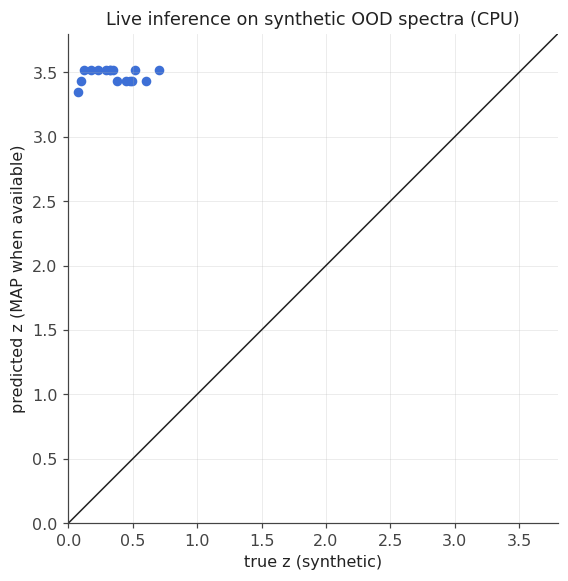

In [11]:
REST_LINES = {"[OII] 3727": 3727.0, "Ca K 3934": 3934.0, "Ca H 3969": 3969.0,
              "Hbeta 4861": 4861.0, "[OIII] 5007": 5007.0, "Halpha 6563": 6563.0}

def make_synthetic(z, rng, wave_in):
    fl = 0.5 + 0.15 * np.sin(wave_in / 700.0) + rng.normal(0.0, 0.05, wave_in.size)
    for lam in REST_LINES.values():
        obs = lam * (1.0 + z)
        if wave_in[0] <= obs <= wave_in[-1]:
            fl += float(rng.uniform(0.4, 1.2)) * np.exp(-0.5 * ((wave_in - obs) / 5.0) ** 2)
    return fl.astype(np.float32)

if LIVE:
    rng = np.random.default_rng(0)
    # deliberately NOT the model grid: linear spacing, different pixel count
    wave_in = np.linspace(3600.0, 9800.0, 6000).astype(np.float32)
    zt, zp = [], []
    for _ in range(16):
        z = float(rng.uniform(0.02, 0.8))
        res = predict_spectrum(flux=make_synthetic(z, rng, wave_in),
                               wavelength=wave_in, model=model)
        zt.append(z); zp.append(float(res.get("z_pred_map", res["z_pred"])))
    lim = 1.08 * max(1.0, max(zt + zp))
    fig, ax = plt.subplots(figsize=(5.4, 5.4))
    ax.scatter(zt, zp, s=28, color=C_PRIMARY)
    zz = np.linspace(0.0, lim, 10)
    ax.plot(zz, zz, color=INK, lw=1.0)
    ax.set_xlim(0.0, lim); ax.set_ylim(0.0, lim); ax.set_aspect("equal")
    ax.set_xlabel("true z (synthetic)"); ax.set_ylabel("predicted z (MAP when available)")
    ax.set_title("Live inference on synthetic OOD spectra (CPU)")
    plt.tight_layout(); plt.show()
else:
    print("(skipped)")

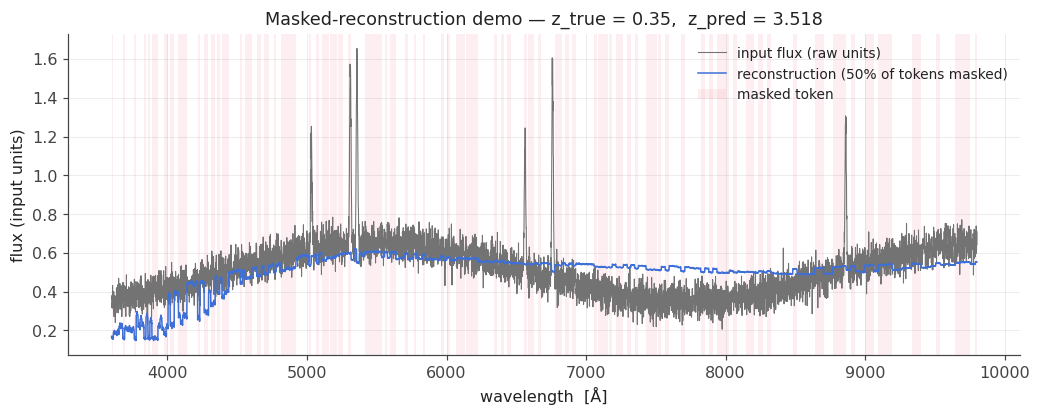

In [12]:
if LIVE:
    rng = np.random.default_rng(7)
    z_demo = 0.35
    fl = make_synthetic(z_demo, rng, wave_in)
    res = predict_spectrum(flux=fl, wavelength=wave_in, model=model, mask_ratio=0.5)
    mask_tok = res["spectrum_mask"]; mw = res["model_wavelength"]
    P = int(np.ceil(len(mw) / float(len(mask_tok))))
    fig, ax = plt.subplots(figsize=(9.6, 3.9))
    ax.plot(wave_in, fl, color="0.45", lw=0.7, label="input flux (raw units)")
    ax.plot(wave_in, res["reconstruction_input_grid"], color=C_PRIMARY, lw=1.0,
            label="reconstruction (50% of tokens masked)")
    lo, hi = ax.get_ylim()
    first = True
    for t in np.where(mask_tok)[0]:
        seg = mw[t * P: (t + 1) * P]
        if len(seg) == 0:
            continue
        ax.axvspan(float(seg[0]), float(seg[-1]), color=C_ACCENT, alpha=0.10, lw=0,
                   label="masked token" if first else None)
        first = False
    ax.set_ylim(lo, hi)
    ax.set_xlabel("wavelength  [Å]"); ax.set_ylabel("flux (input units)")
    ax.set_title("Masked-reconstruction demo — z_true = %.2f,  z_pred = %.3f"
                 % (z_demo, float(res.get("z_pred_map", res["z_pred"]))))
    ax.legend(loc="upper right", fontsize=9)
    plt.tight_layout(); plt.show()
else:
    print("(skipped)")

## 5 · Summary — v1 → v2.1 on the canonical held-out split

All numbers below come from the **same 2,000 held-out DESI spectra** (valid-label examples
80,000–82,000, `--skip-examples 80000`), never seen in training by either model. The v2.1
column uses `z_pred_map`, its official prediction. Full machine-readable comparison (both
checkpoints, all release gates) in `runs/desi_80k_classhead_v21/comparison.json`.

| metric (2,000 held-out DESI spectra) | v1 baseline | **v2.1 (fine-tune, MAP)** |
|---|---|---|
| catastrophic outlier fraction η₀.₁₅ | 22.6 % | **15.0 %** |
| σ_NMAD | 0.083 | **0.030** |
| MAE_norm ⟨\|Δz\|/(1+z)⟩ | 0.107 | **0.096** |
| η₀.₁₅ in z ∈ [1.5, 2.5) | 82.7 % | **23.5 %** |
| prediction ceiling max z_pred | 2.00 | **3.52** |
| masked reconstruction RMSE (arcsinh space) | 0.819 | **0.817** |

**Mapping to the grader feedback:**

- *"high bias"* → the v1 bias came from a scalar regression head collapsing toward the
  conditional mean and averaging line-misidentification modes. v2.1 replaces it with a
  100-bin classification posterior over log(1+z); taking the argmax commits to a mode
  instead of averaging, and the prediction ceiling (z ≈ 2.0 → 3.5) is gone.
- *"large catastrophic outlier fraction"* → η₀.₁₅ drops 22.6 % → **15.0 %** globally and
  82.7 % → **23.5 %** in the z ∈ [1.5, 2.5) regime that dominated the failure.
- *"lacked a ready-to-run evaluation notebook and plots"* → this notebook, runnable
  offline from shipped artifacts; the executed v1 "before" is preserved in
  [`evaluation_v1_baseline.ipynb`](evaluation_v1_baseline.ipynb).

**Provenance & honesty notes:** v2.1 is a *fine-tune of v1* with a new classification
head — not a model trained from scratch. Reported v1 numbers were re-measured on this
canonical held-out split (the historical 25.1 % / 27.3 % figures came from earlier,
differently-defined evaluation windows). The promotion decision was made by the joint
release gates in `comparison.json` (`decision: promote_v2_1`), with
`checkpoint_last.pt` as the winning checkpoint.